## Base Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
input_path = "aws_stations_with_synthetic_humidity.csv"
output_dir = "C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/05_outputs"

In [3]:
plots_dir = "C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/05_outputs/plots"

In [4]:
import os 
os.makedirs(plots_dir,exist_ok=True)

## Load The Data

In [5]:
df = pd.read_csv("C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/01_data/02_processed/aws_stations_with_synthetic_humidity_clean.csv")

In [6]:
df.head()

,cluster,station_name,state,district,date_of_record,avg_temp,min_temp,max_temp,relative_humidity,wind_speed,air_pressure,rainfall,elevation,latitude,longitude
0,Punjab Plains,Ambala,HR,Ambala,2021-01-01,9.1,4.4,13.6,78.400208,NaN,NaN,NaN,271,30.3833,76.7667
1,Punjab Plains,Ambala,HR,Ambala,2021-01-02,11.8,5.7,14.6,75.500032,5.8,1017.4,2.0,271,30.3833,76.7667
2,Punjab Plains,Ambala,HR,Ambala,2021-01-03,14.6,9.4,20.0,73.037773,11.5,1015.1,7.9,271,30.3833,76.7667
3,Punjab Plains,Ambala,HR,Ambala,2021-01-04,18.1,11.2,23.2,64.934059,9.1,1016.9,0.0,271,30.3833,76.7667
4,Punjab Plains,Ambala,HR,Ambala,2021-01-05,16.2,14.5,24.1,67.400295,13.2,1016.4,0.3,271,30.3833,76.7667


In [7]:
df.sample(5)

,cluster,station_name,state,district,date_of_record,avg_temp,min_temp,max_temp,relative_humidity,wind_speed,air_pressure,rainfall,elevation,latitude,longitude
5113,Punjab Plains,Chandigarh / Surajpur,CH,Chandigarh,2022-10-01,25.7,21.4,30.4,72.726086,7.0,1005.6,0.0,347,30.7333,76.8833
13361,Kerala-TN Western Ghats,Palakkad,KL,Palakkad,2024-11-26,26.9,23.9,32.3,88.891871,11.6,1009.2,17.5,95,10.7667,76.6500
3270,Isolated Edge-Case,Car Nicobar,AN,Nicobar,2021-10-10,26.7,25.8,28.3,70.709324,25.5,1007.4,15.0,9,9.1667,92.8333
18995,Kerala-TN Western Ghats,Thrissur,KL,Thrissur,2023-12-23,27.1,23.8,32.5,75.060614,16.0,1012.5,0.0,40,10.5167,76.2167
19344,Kerala-TN Western Ghats,Thrissur,KL,Thrissur,2024-12-18,25.5,21.3,31.0,81.217575,8.4,1009.5,0.0,40,10.5167,76.2167


In [8]:
df.shape

(20888, 15)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20888 entries, 0 to 20887
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cluster            20888 non-null  str    
 1   station_name       20888 non-null  str    
 2   state              20888 non-null  str    
 3   district           20888 non-null  str    
 4   date_of_record     20888 non-null  str    
 5   avg_temp           20888 non-null  float64
 6   min_temp           20885 non-null  float64
 7   max_temp           20888 non-null  float64
 8   relative_humidity  20888 non-null  float64
 9   wind_speed         20851 non-null  float64
 10  air_pressure       20847 non-null  float64
 11  rainfall           20867 non-null  float64
 12  elevation          20888 non-null  int64  
 13  latitude           20888 non-null  float64
 14  longitude          20888 non-null  float64
dtypes: float64(9), int64(1), str(5)
memory usage: 2.4 MB


In [10]:
Raw_row_count = len(df)

In [11]:
Raw_row_count

20888

## Basic Type fixes 

In [12]:
df['date_of_record'] = pd.to_datetime(df['date_of_record'])

In [13]:
# sort by station then date 
df = df.sort_values(["station_name","date_of_record"]).reset_index(drop=True)

## Structural Overview

print("\nNumber of unique stations:",df["station_name"].unique())
print("Number of unique clusters:", df['cluster'].nunique())
print("\nRows per cluster:")
print(df['cluster'].value_counts())

print("\nRows per station:")
print(df.groupby("station_name").size())

In [14]:
print("\nDate range:", df['date_of_record'].min().date(),'to',df['date_of_record'].max().date())


Date range: 2021-01-01 to 2025-02-10


## Missing Values

In [15]:
numeric_cols = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "relative_humidity",
    "wind_speed",
    "air_pressure",
    "rainfall",
    "elevation",
    "latitude",
    "longitude",
]

In [16]:
missing_counts = df[numeric_cols].isna().sum()
missing_pct    = (df[numeric_cols].isna().mean()*100).round(3)

In [17]:
print("\nMissing value counts:")
print(missing_counts)

print("\nMissing value percentage:")
print(missing_pct)


Missing value counts:
avg_temp              0
min_temp              3
max_temp              0
relative_humidity     0
wind_speed           37
air_pressure         41
rainfall             21
elevation             0
latitude              0
longitude             0
dtype: int64

Missing value percentage:
avg_temp             0.000
min_temp             0.014
max_temp             0.000
relative_humidity    0.000
wind_speed           0.177
air_pressure         0.196
rainfall             0.101
elevation            0.000
latitude             0.000
longitude            0.000
dtype: float64


In [18]:
missing_by_station = df.groupby("station_name")[numeric_cols].apply(lambda g:g.isna().sum())

In [19]:
missing_by_station.to_csv(f"{output_dir}/missing_by_station.csv")

In [20]:
#Visualize where the missing values sit 
plt.figure (figsize=(10,5))
sns.heatmap(df[numeric_cols].isna().T, cbar=False, cmap="Reds")
plt.title("Missing Value Map (raw data — untouched)")
plt.xlabel("Row index")
plt.tight_layout()
plt.savefig(f"{plots_dir}/01_missing_value_heatmap.png", dpi=120)
plt.close()

## Structural Gap Analysis

In [21]:
gap_rows = []
for station, g in df.groupby("station_name"):
    g = g.sort_values("date_of_record")
    full_calendar = pd.date_range(g["date_of_record"].min(), g["date_of_record"].max(), freq="D")
    missing_dates = full_calendar.difference(g["date_of_record"])
    gap_rows.append({
        "station_name": station,
        "expected_days": len(full_calendar),
        "actual_rows": len(g),
        "missing_days": len(missing_dates),
    })
 

In [22]:

gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(f"{output_dir}/station_date_gaps.csv", index=False)
print("\nStructural (whole-row) gaps per station:")
print(gap_df)


Structural (whole-row) gaps per station:
                    station_name  expected_days  actual_rows  missing_days
0                         Ambala           1502         1500             2
1                        Bikaner           1501         1489            12
2                    Car Nicobar           1501         1487            14
3          Chandigarh / Surajpur           1502         1498             4
4   Cochin Int. Airport / Kaladi           1502         1491            11
5         Coimbatore / Peelamedu           1502         1498             4
6                       Ludhiana           1502         1495             7
7                          Mandi           1501         1489            12
8                       Palakkad           1501         1488            13
9                        Patiala           1502         1500             2
10                Shimla / Kanda           1500         1488            12
11     Sundernagar / Sundarnagar           1501         14

## Descriptive statistics

In [23]:
print("\nDescribe (numeric columns):")
print(df[numeric_cols].describe().T)


Describe (numeric columns):
                     count         mean         std         min          25%  \
avg_temp           20888.0    23.699200    6.607736    2.200000    19.700000   
min_temp           20885.0    18.972693    7.277017   -5.600000    13.500000   
max_temp           20888.0    29.597759    6.355729    4.600000    26.200000   
relative_humidity  20888.0    71.738178   10.452981   36.891585    64.817508   
wind_speed         20851.0     9.076773    5.009697    1.500000     5.700000   
air_pressure       20847.0  1009.949954    5.533603  992.000000  1006.900000   
rainfall           20867.0     3.942584   10.007590    0.000000     0.000000   
elevation          20888.0   388.232286  404.037306    8.000000    95.000000   
latitude           20888.0    23.419455    9.793319    9.166700    10.766700   
longitude          20888.0    77.546770    4.330009   73.300000    76.266700   

                           50%          75%        max  
avg_temp             25.800000   

## Cross variable consistency checks

In [24]:
# Temperature order consistency
df["flag_temp_order_violation"] = (
    (df["min_temp"] > df["avg_temp"])
    | (df["avg_temp"] > df["max_temp"])
)

In [25]:
df["flag_humidity_out_of_range"] = (
    (df["relative_humidity"] < 0)
    | (df["relative_humidity"] > 100)
)

In [26]:
df["flag_negative_rainfall"] = df["rainfall"] < 0

In [27]:
df["flag_negative_wind"] = df["wind_speed"] < 0

In [28]:

print("\nConsistency check violation counts:")

print(
    "  temp order violation:",
    df["flag_temp_order_violation"].sum()
)

print(
    "  humidity out of range:",
    df["flag_humidity_out_of_range"].sum()
)

print(
    "  negative rainfall:",
    df["flag_negative_rainfall"].sum()
)

print(
    "  negative wind speed:",
    df["flag_negative_wind"].sum()
)


Consistency check violation counts:
  temp order violation: 2
  humidity out of range: 0
  negative rainfall: 0
  negative wind speed: 0


## Outlier Detection

In [29]:
df["month"] = df["date_of_record"].dt.month

In [30]:
def flag_outliers_iqr(group, cols):
    flags = pd.DataFrame(index=group.index)
    for col in cols:
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        flags[f"outlier_{col}"] = (group[col] < lower_bound) | (group[col] > upper_bound)
    return flags

In [31]:
outlier_cols = [
    "avg_temp",
    "relative_humidity",
    "air_pressure",
]

outlier_flags = df.groupby(
    ["cluster", "month"],
    group_keys=False
).apply(
    lambda g: flag_outliers_iqr(g, outlier_cols)
)

In [32]:
df = pd.concat([df, outlier_flags], axis=1)

In [33]:
print("\nOutlier counts (per-cluster, per-month IQR method):")
for c in outlier_flags.columns:
    print(f"  {c}: {df[c].sum()}")


Outlier counts (per-cluster, per-month IQR method):
  outlier_avg_temp: 146
  outlier_relative_humidity: 107
  outlier_air_pressure: 188


In [34]:
# per-station , per-month baseline 
baseline = df.groupby(["station_name", "month"])[
    ["avg_temp", "min_temp", "max_temp", "relative_humidity", "air_pressure"]
].agg(["mean", "std"])

In [35]:
baseline.columns = ["_".join(c) for c in baseline.columns]
baseline = baseline.reset_index()
baseline.to_csv(f"{output_dir}/station_month_baselines.csv", index=False)
print("\nPer-station, per-month baselines saved to station_month_baselines.csv")


Per-station, per-month baselines saved to station_month_baselines.csv


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["avg_temp"], kde=True, ax=axes[0], color="tomato")
axes[0].set_title("Avg Temperature (°C)")
sns.histplot(df["relative_humidity"], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Relative Humidity (%)")
sns.histplot(df["air_pressure"].dropna(), kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Air Pressure (hPa)")
plt.tight_layout()
plt.savefig(f"{plots_dir}/02_distributions.png", dpi=120)
plt.close()

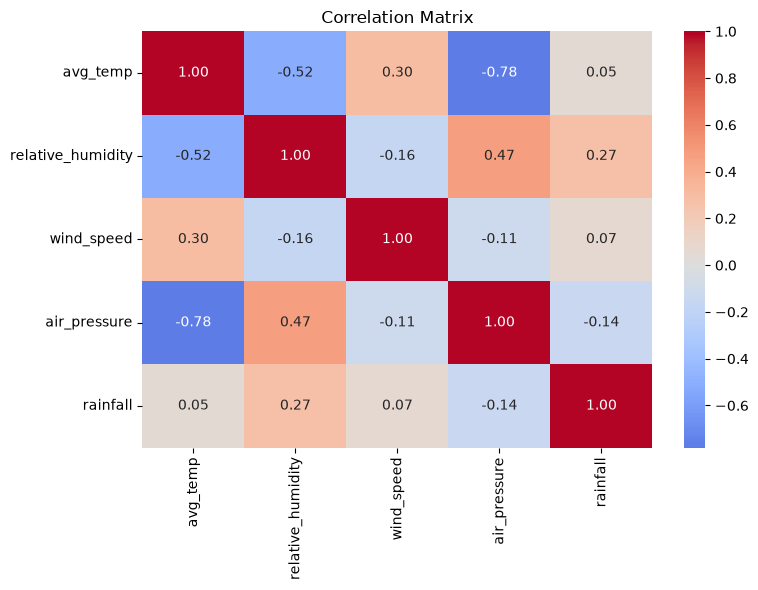

In [37]:
# Correlation matrix between the numeric weather parameters

plt.figure(figsize=(8, 6))

corr = df[
    [
        "avg_temp",
        "relative_humidity",
        "wind_speed",
        "air_pressure",
        "rainfall",
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    f"{plots_dir}/03_correlation_matrix.png",
    dpi=120
)

plt.show()
plt.close()

In [38]:
## Seasonality of temperature by cluster
plt.figure(figsize=(10, 5))
monthly_temp = df.groupby(["cluster", "month"])["avg_temp"].mean().reset_index()
sns.lineplot(data=monthly_temp, x="month", y="avg_temp", hue="cluster", marker="o")
plt.title("Average Temperature Seasonality by Cluster")
plt.xlabel("Month")
plt.ylabel("Avg Temp (°C)")
plt.tight_layout()
plt.savefig(f"{plots_dir}/04_seasonality_temp.png", dpi=120)
plt.close()

In [39]:
# Seasonality of humidity by cluster

plt.figure(figsize=(10, 5))

monthly_hum = (
    df.groupby(["cluster", "month"])["relative_humidity"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=monthly_hum,
    x="month",
    y="relative_humidity",
    hue="cluster",
    marker="o"
)

plt.title("Average Relative Humidity Seasonality by Cluster")
plt.xlabel("Month")
plt.ylabel("Relative Humidity (%)")

plt.tight_layout()

plt.savefig(
    f"{plots_dir}/05_seasonality_humidity.png",
    dpi=120
)

plt.close()

In [40]:
# Pressure spread by station (shows per-station calibration/elevation offsets)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="station_name", y="air_pressure")
plt.xticks(rotation=45, ha="right")
plt.title("Air Pressure Distribution by Station")
plt.tight_layout()
plt.savefig(f"{plots_dir}/06_pressure_by_station.png", dpi=120)
plt.close()
 